In [14]:
import os
import sys
from pathlib import Path
import json
import pickle
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from datasets import load_dataset

# Add project root to path
sys.path.append(os.path.abspath("../../.."))

from src.visual_attn import LlavaNextImageTokenVisualizer
from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 8)

print("✓ Imports loaded")

✓ Imports loaded


## Load Model and Processor
We need the processor to correctly map image tokens to patches.

In [15]:
MODEL_ID = "llava-hf/llava-v1.6-mistral-7b-hf"

print(f"Loading processor for {MODEL_ID}...")
processor = LlavaNextProcessor.from_pretrained(MODEL_ID)
print("✓ Processor loaded")

# Load model (optional if you only need to test mapping, but needed for extraction)
# Uncomment to load model
# print(f"Loading model {MODEL_ID}...")
model = LlavaNextForConditionalGeneration.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, low_cpu_mem_usage=True, device_map="auto"
)
print("✓ Model loaded")

Loading processor for llava-hf/llava-v1.6-mistral-7b-hf...
✓ Processor loaded


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✓ Model loaded


In [16]:
# Load Dataset
print("Loading dataset...")
dataset = load_dataset("francescortu/whoops-aha", split="train")
print(f"✓ Dataset loaded ({len(dataset)} samples)")

Loading dataset...


✓ Dataset loaded (500 samples)


## 2. Experiment Setup
We define the samples and helper functions for the analysis.

In [17]:
# Sample images (same as Gemma experiment)
sample_image = {
    "pirate": 457,
    "zuck": 463,
    "liberty": 12,
    "lennon": 13,
    "liberty2": 63,
    "child_newspaper": 95,
    "zebra": 100,
    "iena": 119,
    "boat": 130,
    "lighthouse": 215,
    "childfire": 216,
    "train": 350,
    "hat": 409,
    "fruit": 2,
    "mask": 26,
    "macbook": 39,
    "fire": 49,
    "sand": 70,
    "penguin": 73,
    "pizza": 99,
}

# Path to segmented images
SEG_DIR = Path("data_whoops_segmented")


def load_segmented_image(image_name):
    """Load the segmented image to identify object patches."""
    # Try jpg and png
    img_path = SEG_DIR / f"{image_name}_sem.jpg"
    if not img_path.exists():
        img_path = SEG_DIR / f"{image_name}_sem.png"

    if not img_path.exists():
        raise FileNotFoundError(f"Segmented image for {image_name} not found")

    image = Image.open(img_path).convert("RGB")
    return image


def detect_non_white_patches_llava(image, visualizer, white_threshold=250):
    """
    Detect which image patches (tokens) contain non-white pixels.
    This identifies patches that correspond to the segmented object.

    Args:
        image: PIL Image of the segmented image (with white background)
        visualizer: LlavaNextImageTokenVisualizer initialized with the original image
        white_threshold: RGB values above this are considered white

    Returns:
        torch.Tensor of shape [num_tokens] with 1 for object patches, 0 for background
    """
    import numpy as np

    # Convert image to numpy
    image_np = np.array(image)

    # Create mask for non-white pixels
    is_white = (
        (image_np[:, :, 0] > white_threshold)
        & (image_np[:, :, 1] > white_threshold)
        & (image_np[:, :, 2] > white_threshold)
    )
    non_white_pixels = ~is_white  # [H, W] boolean mask

    # Now we need to determine which image tokens overlap with non-white regions
    # For each token, we check if its corresponding image region contains non-white pixels

    num_tokens = visualizer.number_of_tokens
    object_patch_mask = torch.zeros(num_tokens, dtype=torch.float32)

    # Get the original image size that was used
    orig_h, orig_w = image_np.shape[:2]

    # For each token, use the visualizer to determine its spatial coverage
    # We'll create a dummy attention vector with one token active at a time
    # and check if it overlaps with non-white regions

    for token_idx in range(num_tokens):
        # Create attention vector with only this token active
        token_attention = torch.zeros(num_tokens)
        token_attention[token_idx] = 1.0

        # Get the heatmap for this token (this shows which pixels it covers)
        heatmap = visualizer.get_raw_heatmap_values(token_attention)  # [H, W]

        # Resize non_white_pixels to match heatmap size
        if non_white_pixels.shape != heatmap.shape:
            from PIL import Image as PILImage

            non_white_img = PILImage.fromarray(non_white_pixels.astype(np.uint8) * 255)
            non_white_img = non_white_img.resize(
                (heatmap.shape[1], heatmap.shape[0]), PILImage.Resampling.NEAREST
            )
            non_white_resized = torch.from_numpy(np.array(non_white_img) > 128)
        else:
            non_white_resized = torch.from_numpy(non_white_pixels)

        # Check if this token's region overlaps with non-white pixels
        # A token is "object" if its spatial region has significant non-white coverage
        token_mask = heatmap > 0  # Pixels covered by this token
        overlap = (token_mask & non_white_resized).sum()
        total_token_pixels = token_mask.sum()

        # If more than 50% of the token's region is non-white, mark it as object
        if total_token_pixels > 0 and overlap > (total_token_pixels * 0.5):
            object_patch_mask[token_idx] = 1.0

    return object_patch_mask

In [18]:
def compute_attention_metrics(attention_vector, object_patch_mask):
    """
    Compute attention metrics on patch-level attention.

    Args:
        attention_vector: torch.Tensor [num_patches] of attention values
        object_patch_mask: torch.Tensor [num_patches] with 1 for object patches, 0 for background

    Returns:
        dict of metrics
    """
    # Ensure same device
    object_patch_mask = object_patch_mask.to(attention_vector.device)

    # Total attention
    total_attention = attention_vector.sum()

    # Attention on object patches
    attention_on_object = (attention_vector * object_patch_mask).sum()

    # Percentage of attention on object
    pct_on_object = (attention_on_object / (total_attention + 1e-9)) * 100.0

    # Number of object patches
    num_object_patches = object_patch_mask.sum()
    num_total_patches = len(object_patch_mask)
    num_background_patches = num_total_patches - num_object_patches

    # Percentage of patches that are object
    pct_area = (num_object_patches / num_total_patches) * 100.0

    # Concentration Ratio: (% attention on object) / (% area of object)
    concentration_ratio = pct_on_object / (pct_area + 1e-9)

    # Average attention per patch
    avg_attn_on_object = attention_on_object / (num_object_patches + 1e-9)
    avg_attn_on_background = (total_attention - attention_on_object) / (
        num_background_patches + 1e-9
    )

    # Ratio of average attention (object vs background)
    avg_ratio = avg_attn_on_object / (avg_attn_on_background + 1e-9)

    return {
        "pct_on_object": pct_on_object.item(),
        "concentration_ratio": concentration_ratio.item(),
        "avg_ratio": avg_ratio.item(),
        "pct_area": pct_area.item(),
        "num_object_patches": num_object_patches.item(),
        "num_total_patches": num_total_patches,
    }

## 3. Attention Extraction & Analysis Loop

Since we don't have a pre-computed cache for LLaVA (or it's complex to cache), we will run the model inference here for the selected samples.

**Note**: You need to define which heads are "Counterfactual" and which are "Random".
If you have identified them, list them below. Otherwise, we'll use placeholders.

In [19]:
# TODO: Replace with actual identified heads for LLaVA
# Format: (layer, head_index)
CFACT_HEADS = [
    (15, 0),
    (15, 1),
    (16, 5),  # Example placeholders
]

RANDOM_HEADS = [
    (5, 5),
    (10, 10),
    (20, 20),  # Example placeholders
]


def find_image_token_positions(input_ids, image_token_id=32000):
    """
    Find the positions of image tokens in the input_ids sequence.
    For LLaVA-NeXT, image tokens have ID 32000.

    Returns:
        List of indices where image tokens appear
    """
    # input_ids shape: [batch, seq_len]
    image_positions = (input_ids[0] == image_token_id).nonzero(as_tuple=True)[0]
    return image_positions.tolist()


def analyze_sample(
    image_name, image_index, dataset, model, processor, cfact_heads, random_heads
):
    """
    Run inference on ORIGINAL image and analyze attention relative to SEGMENTED patches.

    Key steps:
    1. Load original image from dataset
    2. Run model inference on original image -> extract attention
    3. Load segmented image to identify object patches
    4. Compute statistics: attention on object patches vs background patches
    """
    # 1. Load Original Image from Dataset (for Inference)
    original_image = dataset[image_index]["image"].convert("RGB")

    # 2. Prepare Inputs and Run Inference on ORIGINAL IMAGE
    prompt = "[INST] <image>\nDescribe this image. [/INST]"

    inputs = processor(text=prompt, images=original_image, return_tensors="pt")
    if hasattr(model, "device"):
        inputs = inputs.to(model.device)

    # 3. Run Model with Attention
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    # 4. Find Image Token Positions
    image_token_positions = find_image_token_positions(
        inputs["input_ids"], image_token_id=32000
    )

    if len(image_token_positions) == 0:
        raise ValueError(f"No image tokens found in sequence for {image_name}")

    # 5. Initialize visualizer with ORIGINAL IMAGE
    visualizer = LlavaNextImageTokenVisualizer(original_image, processor)
    num_img_tokens = visualizer.number_of_tokens

    # 6. Load SEGMENTED image to identify object patches
    seg_image = load_segmented_image(image_name)
    object_patch_mask = detect_non_white_patches_llava(seg_image, visualizer)

    num_object_patches = object_patch_mask.sum().item()
    num_total_patches = len(object_patch_mask)

    print(f"\n{'=' * 60}")
    print(f"Sample: {image_name} (index {image_index})")
    print(f"  Sequence length: {outputs.attentions[0].shape[-1]}")
    print(
        f"  Image tokens: {len(image_token_positions)} at positions {image_token_positions[:3]}..."
    )
    print(f"  Expected tokens: {num_img_tokens}")
    print(
        f"  Object patches: {num_object_patches}/{num_total_patches} ({num_object_patches / num_total_patches * 100:.1f}%)"
    )

    # Verify we have the right number of image tokens
    if len(image_token_positions) != num_img_tokens:
        print(f"  ⚠️ Warning: Token count mismatch")

    # 7. Extract and aggregate attention across heads
    def aggregate_attention_for_heads(head_list):
        """Extract attention from specified heads and average"""
        accumulated_attention = None

        for layer, head in head_list:
            # Get attention matrix: [batch, heads, seq, seq]
            # We want attention FROM the last token TO all tokens
            attn_matrix = outputs.attentions[layer][0, head, -1, :]  # [seq_len]

            # Extract attention only for image token positions
            img_attn = attn_matrix[image_token_positions]  # [num_img_tokens]

            # Handle size mismatch
            if len(img_attn) != num_img_tokens:
                if len(img_attn) > num_img_tokens:
                    img_attn = img_attn[:num_img_tokens]
                else:
                    padding = torch.zeros(
                        num_img_tokens - len(img_attn), device=img_attn.device
                    )
                    img_attn = torch.cat([img_attn, padding])

            if accumulated_attention is None:
                accumulated_attention = img_attn
            else:
                accumulated_attention += img_attn

        # Average across heads
        avg_attention = accumulated_attention / len(head_list)
        return avg_attention

    # 8. Get averaged attention for both head groups
    attention_cfact = aggregate_attention_for_heads(cfact_heads)
    attention_random = aggregate_attention_for_heads(random_heads)

    # 9. Compute metrics (attention on object patches vs background)
    metrics_cfact = compute_attention_metrics(attention_cfact, object_patch_mask)
    metrics_random = compute_attention_metrics(attention_random, object_patch_mask)

    print(
        f"  Counterfactual: {metrics_cfact['pct_on_object']:.1f}% attention on object"
    )
    print(f"  Random: {metrics_random['pct_on_object']:.1f}% attention on object")

    return metrics_cfact, metrics_random

## 4. Run Analysis
Iterate over samples and collect results.

In [ ]:
# Main loop
all_metrics_cfact = []
all_metrics_random = []

# Only run if model is loaded
if "model" in locals() and "dataset" in locals():
    print(f"Analyzing {len(sample_image)} samples...")
    print("=" * 60)

    for name, idx in sample_image.items():
        try:
            m_cfact, m_rand = analyze_sample(
                name, idx, dataset, model, processor, CFACT_HEADS, RANDOM_HEADS
            )
            m_cfact["image"] = name
            m_rand["image"] = name
            all_metrics_cfact.append(m_cfact)
            all_metrics_random.append(m_rand)
        except Exception as e:
            print(f"\n❌ Error analyzing {name}: {e}")
            import traceback

            traceback.print_exc()

    print("\n" + "=" * 60)
    print("ANALYSIS COMPLETE")
    print("=" * 60)

    # Convert to DataFrame
    df_cfact = pd.DataFrame(all_metrics_cfact)
    df_random = pd.DataFrame(all_metrics_random)

    print("\n📊 Results (Counterfactual Heads):")
    print(
        df_cfact[
            ["image", "pct_on_object", "concentration_ratio", "avg_ratio", "pct_area"]
        ].to_string()
    )
    print("\n📈 Statistics:")
    print(df_cfact[["pct_on_object", "concentration_ratio", "avg_ratio"]].describe())

    print("\n📊 Results (Random Heads):")
    print(
        df_random[
            ["image", "pct_on_object", "concentration_ratio", "avg_ratio", "pct_area"]
        ].to_string()
    )
    print("\n📈 Statistics:")
    print(df_random[["pct_on_object", "concentration_ratio", "avg_ratio"]].describe())

    # Compare means
    print("\n🔍 Comparison (Counterfactual vs Random):")
    print(
        f"  Avg % on object: {df_cfact['pct_on_object'].mean():.1f}% vs {df_random['pct_on_object'].mean():.1f}%"
    )
    print(
        f"  Avg concentration: {df_cfact['concentration_ratio'].mean():.2f} vs {df_random['concentration_ratio'].mean():.2f}"
    )
    print(
        f"  Avg ratio: {df_cfact['avg_ratio'].mean():.2f} vs {df_random['avg_ratio'].mean():.2f}"
    )

else:
    if "model" not in locals():
        print("❌ Model not loaded. Please run the model loading cell.")
    if "dataset" not in locals():
        print("❌ Dataset not loaded. Please run the dataset loading cell.")

Analyzing 20 samples...


  0%|          | 0/20 [00:00<?, ?it/s]`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


LLaVA Image range: [0.0, 254.0]
Sample: pirate
  Sequence length: 2943
  Image token positions: 2928 tokens at indices [5, 6, 7]...
  Expected image tokens: 2928


  5%|▌         | 1/20 [00:01<00:20,  1.10s/it]

✓ pirate: cfact=15.7%, random=26.2%
LLaVA Image range: [0.0, 255.0]
Sample: zuck
  Sequence length: 2943
  Image token positions: 2928 tokens at indices [5, 6, 7]...
  Expected image tokens: 2928


...

✓ sand: cfact=45.4%, random=57.7%
LLaVA Image range: [0.0, 255.0]
Sample: penguin
  Sequence length: 2943
  Image token positions: 2928 tokens at indices [5, 6, 7]...
  Expected image tokens: 2928


 95%|█████████▌| 19/20 [00:16<00:00,  1.16it/s]

✓ penguin: cfact=90.2%, random=86.8%
LLaVA Image range: [0.0, 253.0]
Sample: pizza
  Sequence length: 2943
  Image token positions: 2928 tokens at indices [5, 6, 7]...
  Expected image tokens: 2928


100%|██████████| 20/20 [00:16<00:00,  1.18it/s]

✓ pizza: cfact=3.9%, random=12.4%

📊 Results (Counterfactual Heads):
              image  pct_on_mask  concentration_ratio  avg_ratio
0            pirate    15.650025             0.493751   0.492664
1              zuck     0.243011             0.140010   0.139698
2           liberty    22.924515             0.705350   0.703354
3            lennon     9.751164             0.517337   0.516083
4          liberty2     1.335200             0.312996   0.312236
5   child_newspaper    11.015921             0.407274   0.406495
6             zebra     5.984069             0.312157   0.311468
7              iena     3.505645             0.570792   0.569743
8              boat     9.204478             0.502083   0.500732
9        lighthouse    37.411293             0.782131   0.780240
10        childfire    59.952145             0.831994   0.830119
11            train    12.658148             0.357107   0.356207
12              hat    16.024717             0.442170   0.441058
13            fruit  

## 5. Visualization
Visualize the distributions of the metrics.

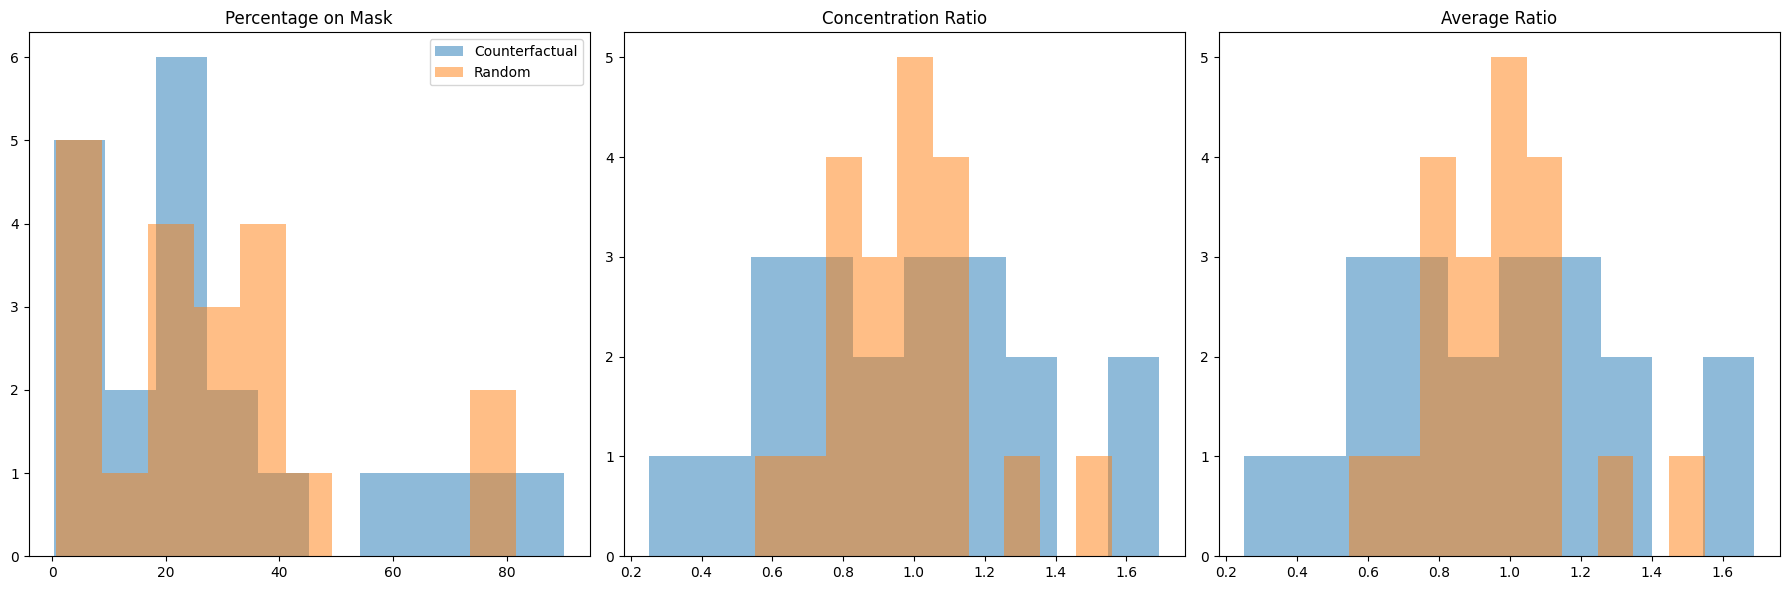

In [ ]:
if "df_cfact" in locals() and not df_cfact.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Percentage on Object
    axes[0].hist(
        df_cfact["pct_on_object"],
        alpha=0.6,
        bins=10,
        label="Counterfactual",
        color="red",
    )
    axes[0].hist(
        df_random["pct_on_object"], alpha=0.6, bins=10, label="Random", color="blue"
    )
    axes[0].set_xlabel("% Attention on Object")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Percentage of Attention on Object Patches")
    axes[0].legend()
    axes[0].axvline(
        df_cfact["pct_on_object"].mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
    )
    axes[0].axvline(
        df_random["pct_on_object"].mean(),
        color="blue",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
    )

    # Concentration Ratio
    axes[1].hist(
        df_cfact["concentration_ratio"],
        alpha=0.6,
        bins=10,
        label="Counterfactual",
        color="red",
    )
    axes[1].hist(
        df_random["concentration_ratio"],
        alpha=0.6,
        bins=10,
        label="Random",
        color="blue",
    )
    axes[1].set_xlabel("Concentration Ratio")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title("Concentration Ratio (normalized by area)")
    axes[1].legend()
    axes[1].axvline(
        df_cfact["concentration_ratio"].mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
    )
    axes[1].axvline(
        df_random["concentration_ratio"].mean(),
        color="blue",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
    )

    # Average Ratio
    axes[2].hist(
        df_cfact["avg_ratio"], alpha=0.6, bins=10, label="Counterfactual", color="red"
    )
    axes[2].hist(
        df_random["avg_ratio"], alpha=0.6, bins=10, label="Random", color="blue"
    )
    axes[2].set_xlabel("Avg Attention Ratio")
    axes[2].set_ylabel("Frequency")
    axes[2].set_title("Object/Background Attention Ratio")
    axes[2].legend()
    axes[2].axvline(
        df_cfact["avg_ratio"].mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
    )
    axes[2].axvline(
        df_random["avg_ratio"].mean(),
        color="blue",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
    )

    plt.tight_layout()
    plt.show()

    print("\n📊 Visual Summary:")
    print(f"Red lines = Counterfactual heads mean")
    print(f"Blue lines = Random heads mean")